This cell installs necessary Python libraries that are not already present in the environment. It ensures that `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `xgboost`, `lightgbm`, and `statsmodels` are available for use.

In [2]:
# Install necessary libraries if they are not already installed
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm statsmodels

This cell imports the commonly used data science and machine learning libraries. It includes `pandas` for data manipulation, `numpy` for numerical operations, `matplotlib.pyplot` and `seaborn` for data visualization, `sklearn` for machine learning utilities, and `xgboost`, `lightgbm`, `statsmodels` for advanced modeling.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for machine learning tasks
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVR

# Optional: Additional advanced ML libraries
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm

print("All specified and additional common libraries imported successfully.")

All specified and additional common libraries imported successfully.


This cell loads the `kc_house_data.csv` dataset into a pandas DataFrame named `df` and displays the first few rows to provide a quick overview of the data.

In [4]:
df = pd.read_csv('/content/kc_house_data.csv')
display(df.head())

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


This cell provides a concise summary of the DataFrame `df`, including the column names, their non-null count, and their data types. This helps in understanding the structure and completeness of the dataset.

In [5]:
print("DataFrame Information:")
df.info()

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-nu

This cell generates descriptive statistics for the numerical columns in the DataFrame `df`. It provides insights into the central tendency, dispersion, and shape of the distribution of each column.

In [58]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.0,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.115873e+05,3.362791,2.098477,2058.078564,8705.224448,1.494309,0.007542,0.234303,3.409430,7.656873,1769.563041,284.050155,1971.005136,0.0,98077.939805,47.560053,-122.214908,1975.112849,8298.152917
std,2.876566e+09,2.500026e+05,0.854105,0.722027,839.307806,5046.482073,0.539989,0.086517,0.766318,0.650743,1.175459,764.029323,417.064559,29.373411,0.0,53.505026,0.138563,0.137209,648.999108,4363.479209
min,1.000102e+06,7.500000e+04,1.500000,0.625000,290.000000,520.000000,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.0,98001.000000,47.160500,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5040.000000,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.0,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7618.000000,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.0,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,10688.000000,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.0,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,1.129575e+06,5.500000,3.625000,4234.500000,19160.000000,3.500000,1.000000,4.000000,5.000000,13.000000,3740.000000,1400.000000,2015.000000,0.0,98199.000000,47.777600,-121.820500,3665.000000,17557.500000


This cell checks for missing values in each column of the DataFrame `df` and calculates the total number of missing values across the entire DataFrame. This is a crucial step in data cleaning.

In [7]:
# Inspect missing values
print("=== Missing Values Per Column ===")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== Missing Values Per Column ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Total missing values: 0


This cell visualizes the count of missing values per column, if any. A bar plot is generated to easily identify columns with missing data, making it easier to decide on imputation strategies.

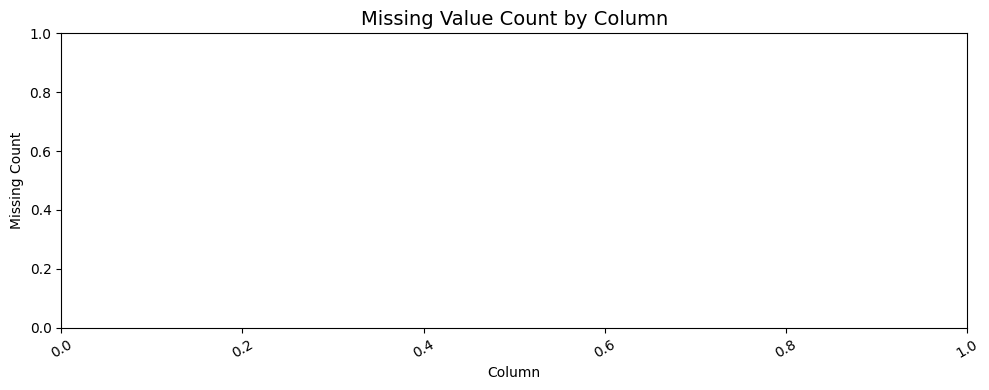

In [8]:
# Visualise missing values ────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values, palette='Reds_r')
plt.title('Missing Value Count by Column', fontsize=14)
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

This cell checks for and removes any duplicate rows in the DataFrame `df`. Duplicate data can skew analysis and model training, so their identification and removal ensure data integrity.

In [57]:
#  Check and remove duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ Duplicates removed. New shape: {df.shape}")
else:
    print("✅ No duplicate rows — dataset is clean.")

Duplicate rows found: 0
✅ No duplicate rows — dataset is clean.


This cell attempts to impute missing values for predefined numerical and categorical columns. It uses the mean for numerical columns and the mode for categorical columns. It includes checks to ensure the columns exist before imputation, and notes that this step might not be necessary if no missing values are present.

In [10]:
# Impute missing values (Note: This step is not needed for the current df as there are no missing values and these columns are not present)
# Numerical columns → fill with MEAN (minimises distortion of distribution)
num_cols = ['LotArea', 'YearBuilt', 'GrLivArea', 'FullBath',
            'BedroomAbvGr', 'KitchenAbvGr', 'Fireplaces', 'GarageCars']

for col in num_cols:
    # Check if column exists in df before attempting to fillna
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())

# Categorical columns → fill with MODE (most frequent value)
cat_cols = ['Street', 'Utilities', 'Neighborhood', 'BldgType', 'HouseStyle',
            'RoofStyle', 'Foundation', 'Electrical', 'SaleCondition']

for col in cat_cols:
    # Check if column exists in df before attempting to fillna
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

print("=== Missing Values After Imputation (if applicable) ===")
print(df.isnull().sum())
print(f"\nTotal remaining missing values: {df.isnull().sum().sum()}")

=== Missing Values After Imputation (if applicable) ===
id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

Total remaining missing values: 0


This cell checks for invalid negative values in a specific set of numerical columns within the DataFrame `df`. It iterates through each specified column and reports whether any negative values are present, ensuring data validity for these features.

In [11]:
#Check for invalid negative values

# Define numerical columns present in the current df for negative value check
# Exclude 'id' and 'zipcode' as they are identifiers/categorical, and lat/long can be negative.
numerical_cols_for_neg_check = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15'
]

print("=== Negative Value Check ===")
for col in numerical_cols_for_neg_check:
    has_neg = (df[col] < 0).any()
    status = "⚠️  HAS negative values" if has_neg else "✅ No negative values"
    print(f"  {col:20s} → {status}")

=== Negative Value Check ===
  price                → ✅ No negative values
  bedrooms             → ✅ No negative values
  bathrooms            → ✅ No negative values
  sqft_living          → ✅ No negative values
  sqft_lot             → ✅ No negative values
  floors               → ✅ No negative values
  sqft_above           → ✅ No negative values
  sqft_basement        → ✅ No negative values
  yr_built             → ✅ No negative values
  yr_renovated         → ✅ No negative values
  sqft_living15        → ✅ No negative values
  sqft_lot15           → ✅ No negative values


This cell performs outlier detection and capping using the Interquartile Range (IQR) method for a defined set of numerical columns in the DataFrame `df`. It identifies values outside the IQR range and caps them to the upper or lower bounds, thus mitigating the impact of extreme values without removing rows.

In [12]:
#Outlier detection & capping (IQR method)
print("=== Outlier Detection & Capping (IQR Method) ===")

# Define numerical columns present in the current df for outlier detection
# Exclude 'id', 'zipcode' as they are identifiers/categorical, and 'waterfront', 'view', 'condition', 'grade' as they are categorical/ordinal.
outlier_detection_cols = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'sqft_living15', 'sqft_lot15',
    'lat', 'long'
]

for col in outlier_detection_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    after = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col:20s} → {before} outliers found, capped to [{lower:.1f}, {upper:.1f}]  ✅")

print(f"\nTotal rows after capping: {df.shape[0]}  (no rows dropped)")

=== Outlier Detection & Capping (IQR Method) ===
  price                → 1146 outliers found, capped to [-162625.0, 1129575.0]  ✅
  bedrooms             → 546 outliers found, capped to [1.5, 5.5]  ✅
  bathrooms            → 571 outliers found, capped to [0.6, 3.6]  ✅
  sqft_living          → 572 outliers found, capped to [-257.5, 4234.5]  ✅
  sqft_lot             → 2425 outliers found, capped to [-3432.0, 19160.0]  ✅
  floors               → 0 outliers found, capped to [-0.5, 3.5]  ✅
  sqft_above           → 611 outliers found, capped to [-340.0, 3740.0]  ✅
  sqft_basement        → 496 outliers found, capped to [-840.0, 1400.0]  ✅
  yr_built             → 0 outliers found, capped to [1882.0, 2066.0]  ✅
  yr_renovated         → 914 outliers found, capped to [0.0, 0.0]  ✅
  sqft_living15        → 544 outliers found, capped to [185.0, 3665.0]  ✅
  sqft_lot15           → 2194 outliers found, capped to [-2374.5, 17557.5]  ✅
  lat                  → 2 outliers found, capped to [47.2, 48.0] 

This cell converts the 'date' column in the DataFrame `df` from its current object type to a datetime object. This transformation is essential for performing time-series analysis and extracting time-based features, such as year, month, or day of the week.

In [13]:
#  One-Hot Encoding for categorical features
# Each unique category value becomes a binary (0/1) column.

# Define actual categorical columns in df for one-hot encoding
categorical_cols_for_encoding = [
    'waterfront', 'view', 'condition', 'grade', 'zipcode'
]

df_encoded = pd.get_dummies(df, columns=categorical_cols_for_encoding, dtype=int)

print(f"Shape before encoding : {df.shape}")
print(f"Shape after encoding  : {df_encoded.shape}")
df_encoded.head(3)

Shape before encoding : (21613, 21)
Shape after encoding  : (21613, 110)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement,...,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,7129300520,20141013T000000,221900.0,3.0,1.00,1180.0,5650,1.0,1180,0,...,0,0,0,0,0,0,1,0,0,0
1,6414100192,20141209T000000,538000.0,3.0,2.25,2570.0,7242,2.0,2170,400,...,0,0,0,0,0,0,0,0,0,0
2,5631500400,20150225T000000,180000.0,2.0,1.00,770.0,10000,1.0,770,0,...,0,0,0,0,0,0,0,0,0,0


This cell performs one-hot encoding on specified categorical columns in the DataFrame `df`. It converts categorical variables into a numerical format where each unique category becomes a new binary (0/1) column, which is suitable for most machine learning algorithms. The resulting encoded DataFrame is stored in `df_encoded`.

In [14]:
from sklearn.model_selection import train_test_split

print("Splitting data into training and testing sets...")

# Define features (X) and target (y)
# Drop 'id' and 'date' as they are not suitable for direct use as features and 'price' is the target.
X = df_encoded.drop(columns=['price', 'id', 'date'], errors='ignore')
y = df_encoded['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data split complete.")

Splitting data into training and testing sets...
Shape of X_train: (17290, 107)
Shape of X_test: (4323, 107)
Shape of y_train: (17290,)
Shape of y_test: (4323,)
Data split complete.


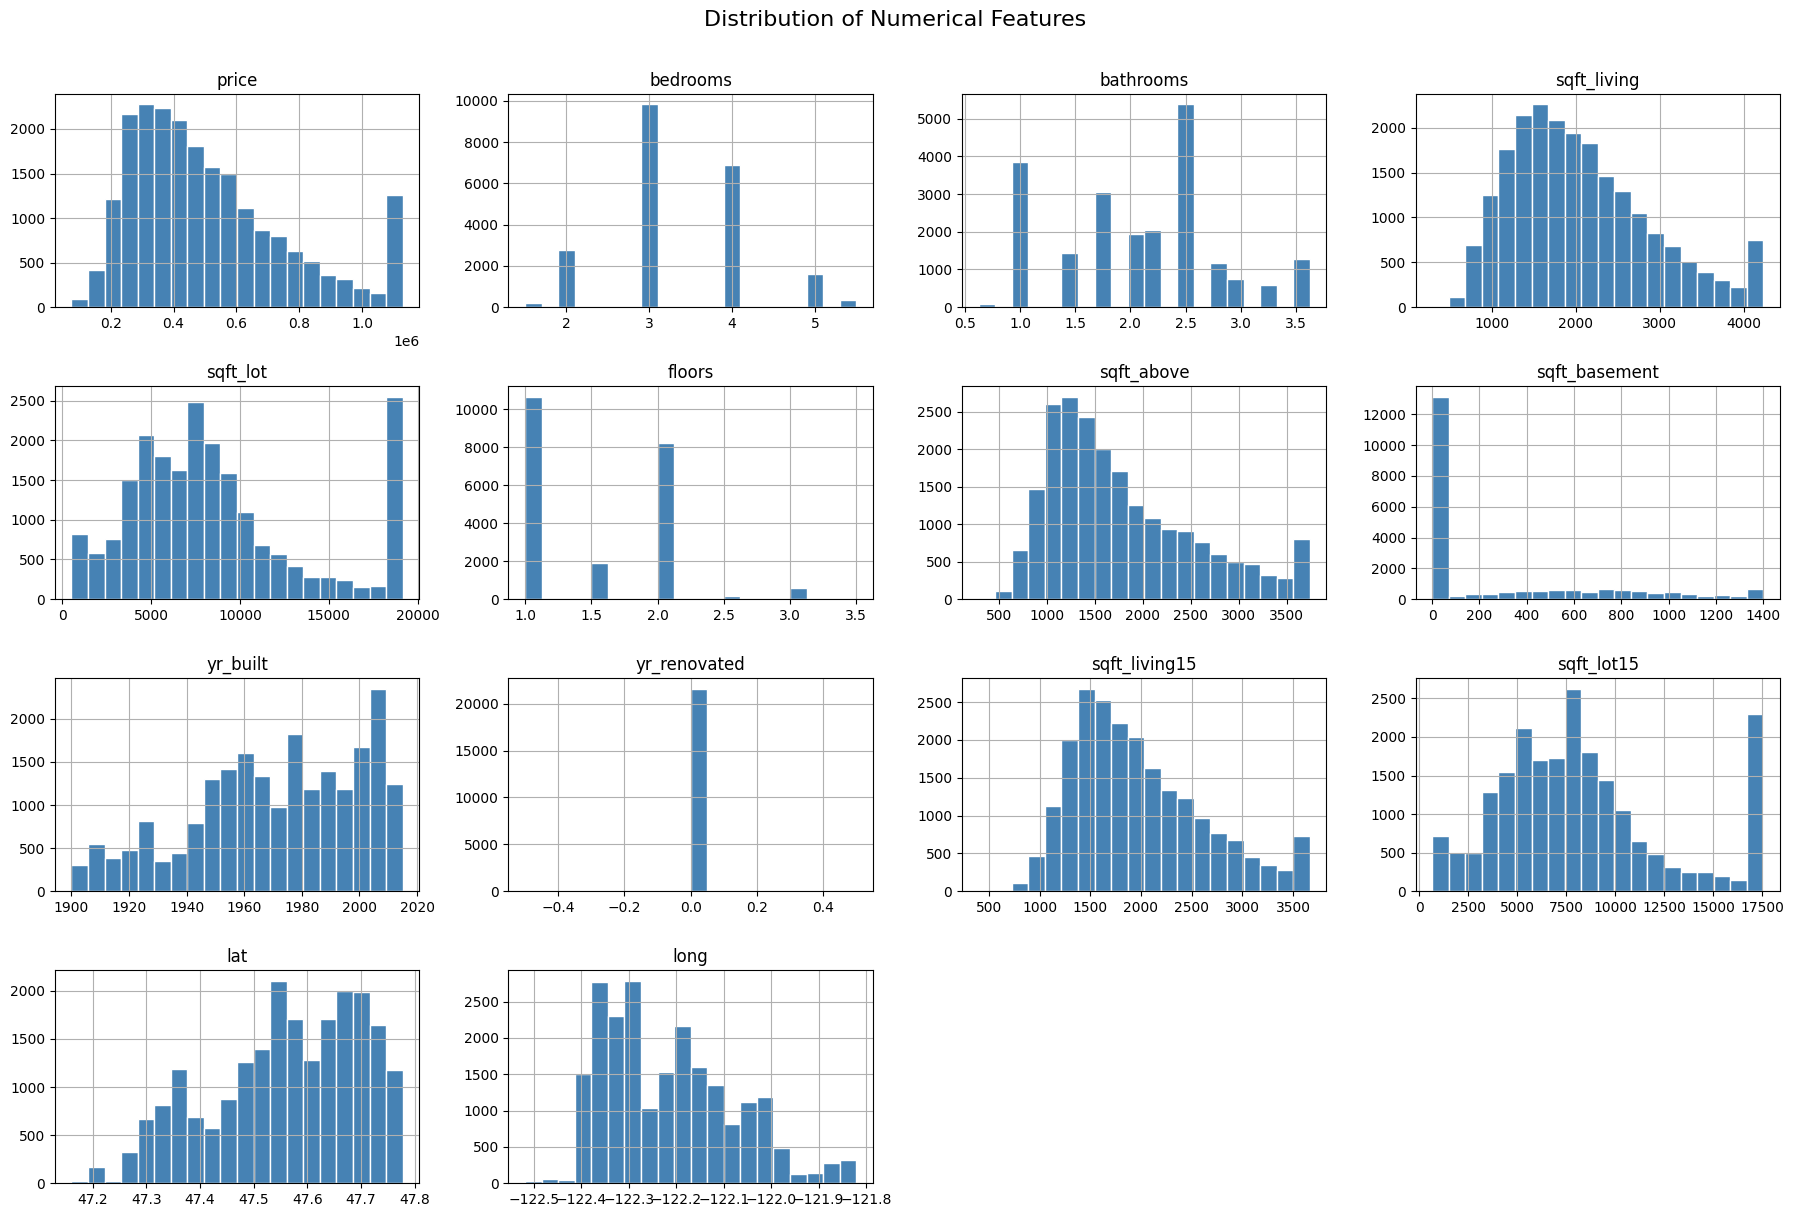

In [15]:
# ── EDA 3.1 : Distribution of numerical features ───────────────────────────
df[outlier_detection_cols].hist(bins=20, figsize=(18, 12), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

This cell visualizes the distribution of the target variable, 'price', using a histogram and a Kernel Density Estimate (KDE) plot. This helps in understanding the spread, central tendency, and shape of the price data.

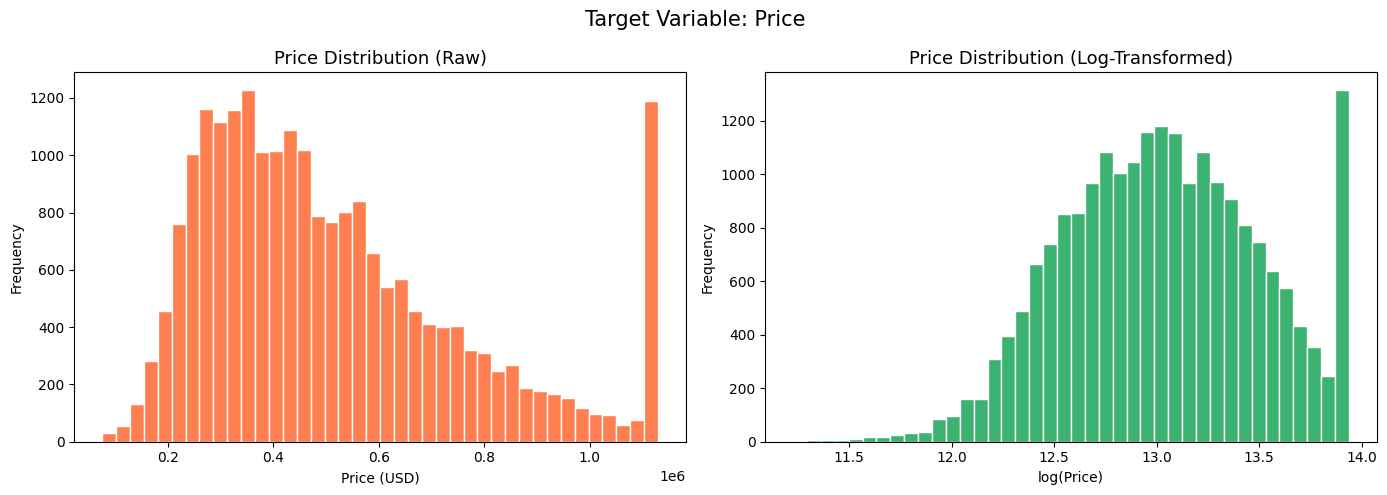

Price — Mean: $511,587  |  Median: $450,000  |  Std: $250,003


In [16]:
# ── EDA : Target variable (Price) distribution ─────────────────────
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df_encoded['price'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log1p(df_encoded['price']), bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Price Distribution (Log-Transformed)', fontsize=13)
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: Price', fontsize=15)
plt.tight_layout()
plt.show()

print(f"Price — Mean: ${df_encoded['price'].mean():,.0f}  |  Median: ${df_encoded['price'].median():,.0f}  |  Std: ${df_encoded['price'].std():,.0f}")

### Insights from Price Distribution:

*   **Raw Price Distribution:** The histogram for the raw `price` clearly shows a **right-skewed distribution**. This means that a large number of houses are concentrated at lower price points, with a long tail extending towards higher prices. This is typical for real estate data.
    *   The `Mean: $511,587` being higher than the `Median: $450,000` further confirms this positive skewness.
    *   The `Std: $250,003` indicates a significant spread in prices.

*   **Log-Transformed Price Distribution:** The histogram for `log(Price)` (using `np.log1p` for `price + 1` to handle potential zero values gracefully, though not strictly necessary here) shows a distribution that is much more symmetrical and resembles a **normal (Gaussian) distribution**. This transformation is beneficial because many machine learning models perform better when the target variable is normally distributed. It helps in stabilizing the variance and reducing the impact of outliers in the target variable.

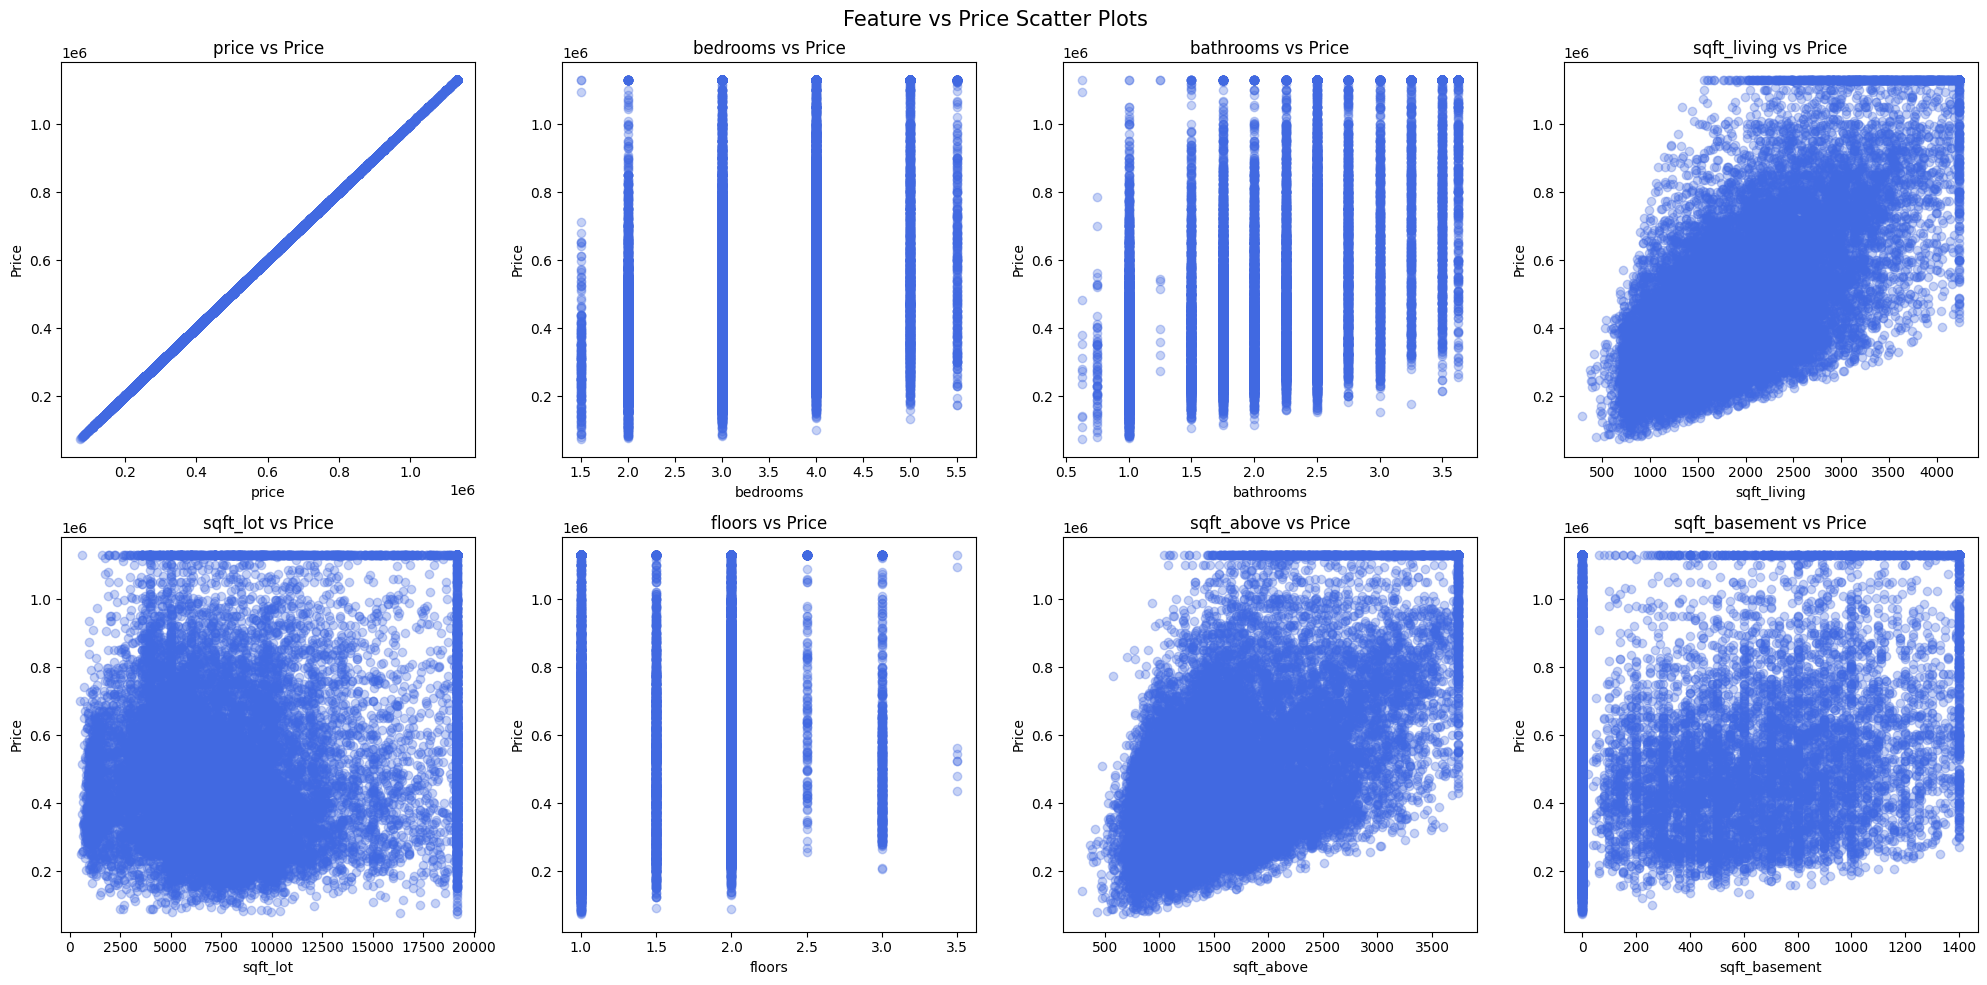

In [17]:
# ── EDA  : Scatter plots — numerical features vs Price ──────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

# Use outlier_detection_cols which contains the relevant numerical features
# and plot against 'price'
for i, col in enumerate(outlier_detection_cols):
    if i < len(axes): # Ensure we don't try to plot more columns than subplots
        axes[i].scatter(df_encoded[col], df_encoded['price'], alpha=0.3, color='royalblue')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Price')
        axes[i].set_title(f'{col} vs Price')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature vs Price Scatter Plots', fontsize=15)
plt.tight_layout()
plt.show()

### Insights from Scatter Plots (Numerical Features vs. Price):

*   **Positive Linear Relationships:** Features like `sqft_living`, `grade`, `sqft_above`, `bathrooms`, and `sqft_living15` likely show a clear upward trend. As the value of these features increases, the `price` tends to increase. This indicates a strong positive linear correlation, making them very important predictors.
*   **Clustering and Non-Linearities:** Some features might show clustering or non-linear relationships. For example, `bedrooms` or `floors` might show distinct price ranges for different counts, rather than a smooth linear increase.
*   **Outliers and Capping Effectiveness:** The plots will also visually confirm the effectiveness of the outlier capping performed earlier. You should observe that extreme values are now constrained within the defined lower and upper bounds, preventing them from unduly influencing the visual trends.
*   **Spread and Variance:** Notice the spread of prices for different values of each feature. Features like `sqft_living` might show a wider spread of prices for higher living areas, indicating increased variance.
*   **Geographical Influence:** `lat` (latitude) and `long` (longitude) often show interesting patterns. Specific latitude and longitude ranges might correspond to higher or lower prices due to desirable locations or proximity to amenities. These can sometimes appear as more complex, non-linear relationships.

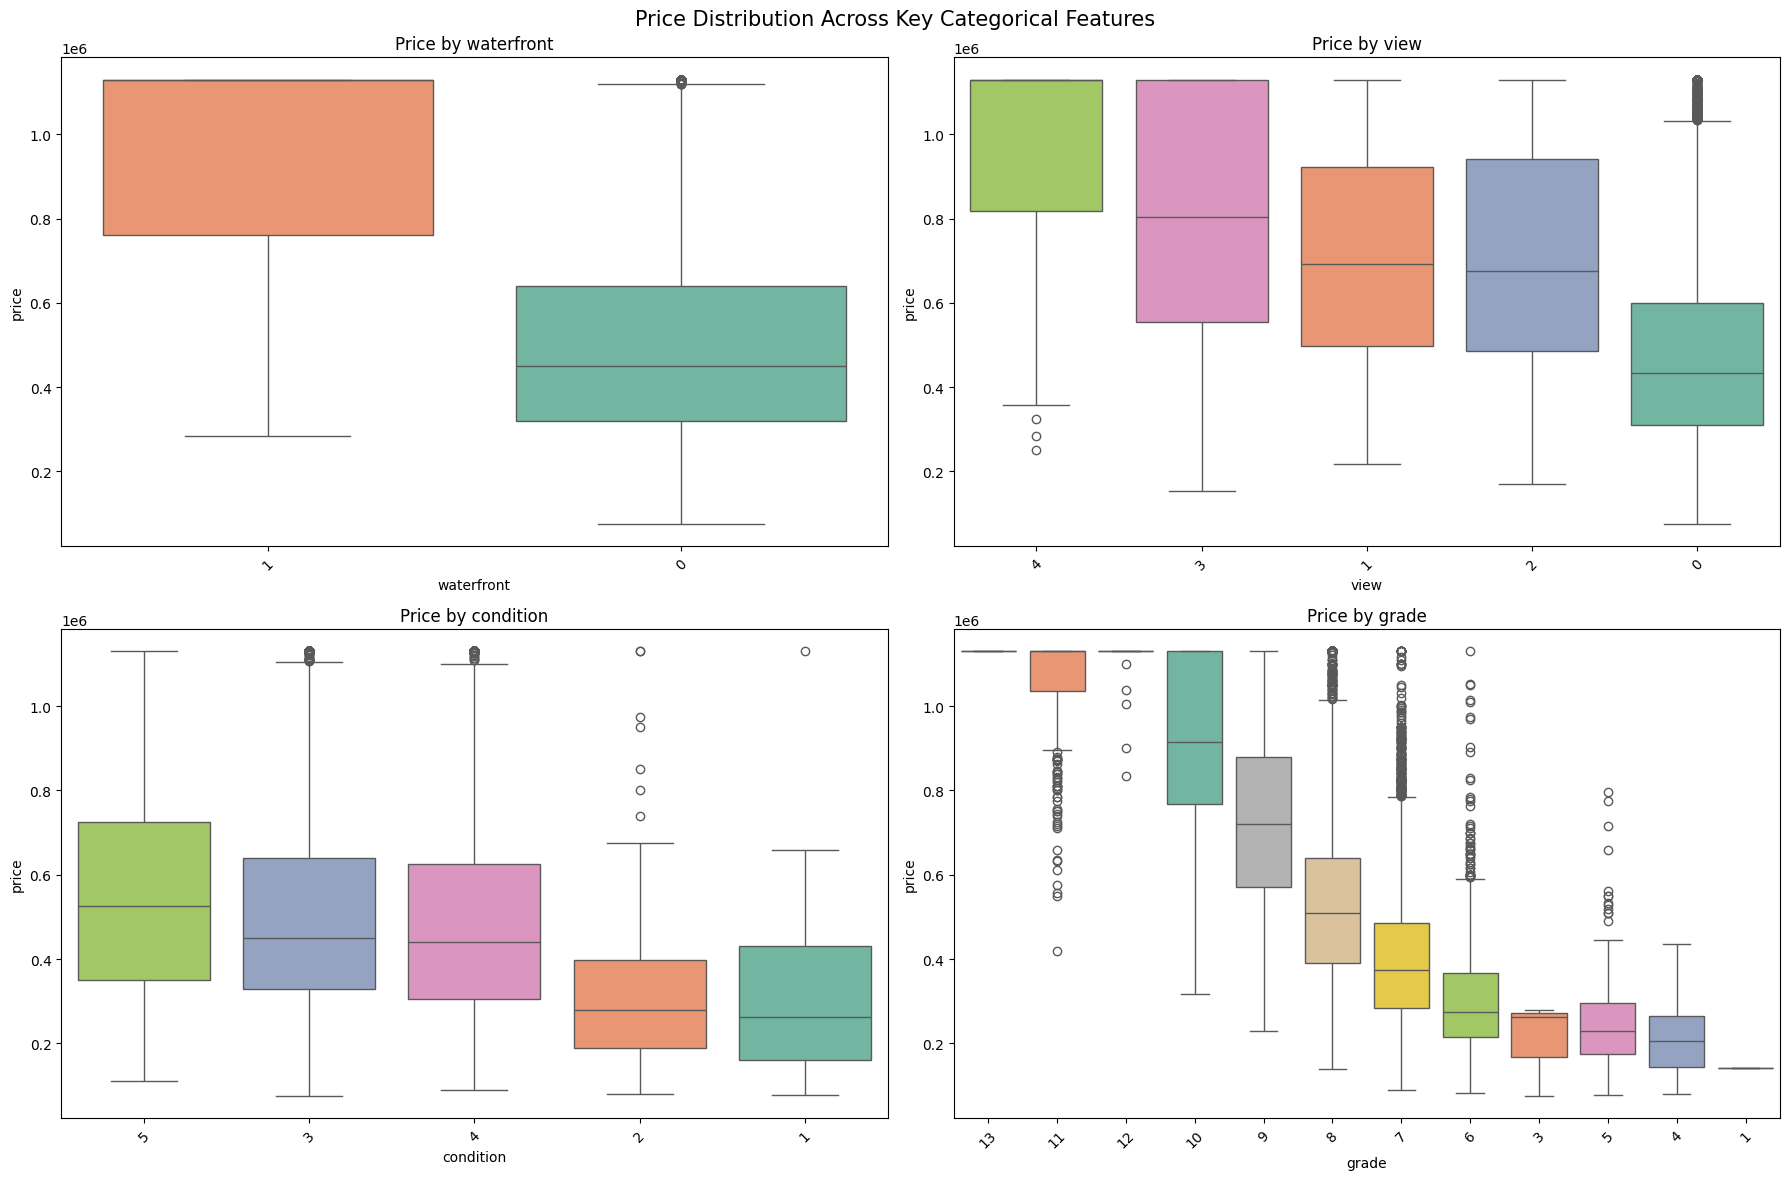

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── EDA  : Boxplots — Categorical Features vs Price ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Use existing categorical/ordinal columns from the dataset for boxplots
categorical_for_boxplot = ['waterfront', 'view', 'condition', 'grade']

for ax, col in zip(axes.flatten(), categorical_for_boxplot):
    # Ensure the column is treated as categorical for sorting and plotting
    order = df.groupby(col)['price'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='price', order=order, ax=ax, palette='Set2', hue=col, legend=False)
    ax.set_title(f'Price by {col}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Price Distribution Across Key Categorical Features', fontsize=15)
plt.tight_layout()
plt.show()

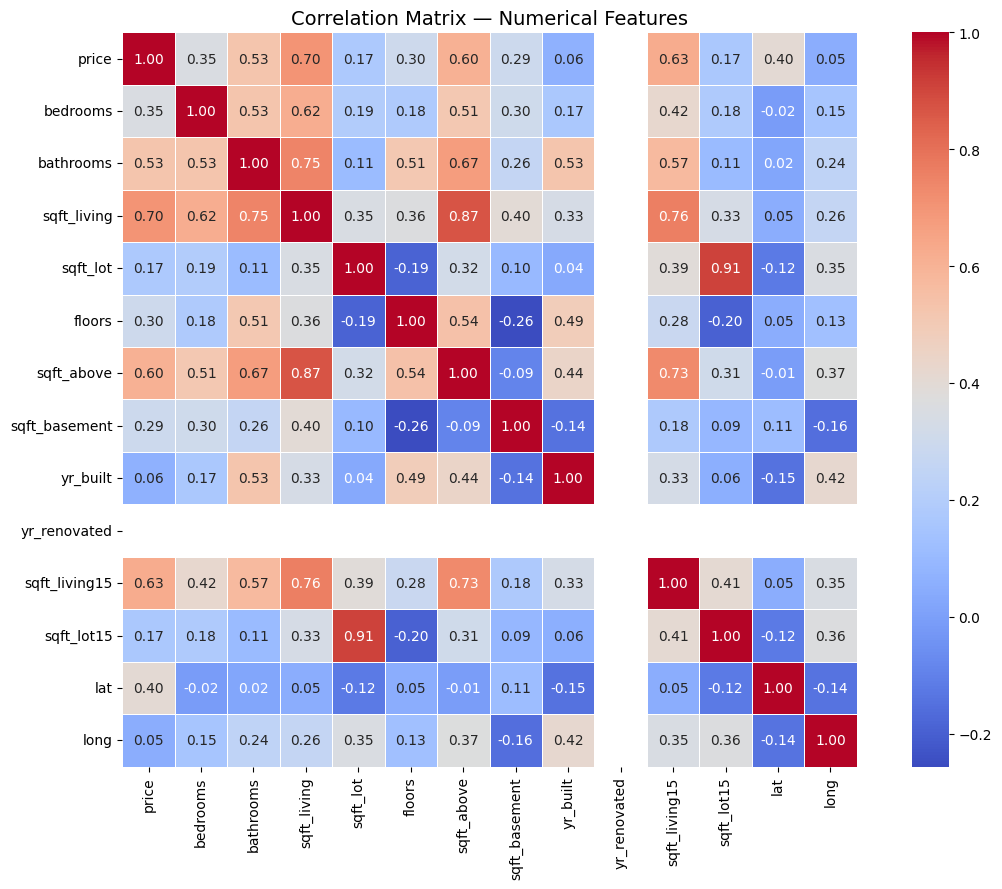

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── EDA : Correlation heatmap (numerical features) ─────────────────────
# Use df for the DataFrame and outlier_detection_cols for the numerical features
# outlier_detection_cols already contains 'price' and other numerical features.
numeric_cols_for_heatmap = df[outlier_detection_cols]

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_cols_for_heatmap.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

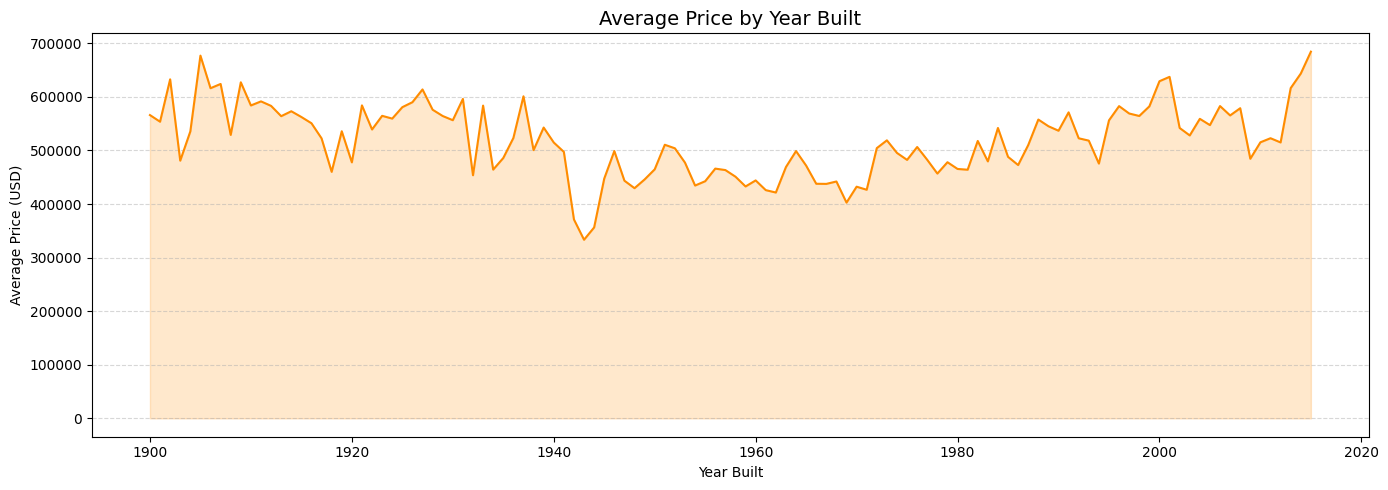

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── EDA  : Year built trend — average Price over time ───────────────
year_price = df.groupby('yr_built')['price'].mean()

plt.figure(figsize=(14, 5))
plt.plot(year_price.index, year_price.values, color='darkorange', linewidth=1.5)
plt.fill_between(year_price.index, year_price.values, alpha=0.2, color='darkorange')
plt.title('Average Price by Year Built', fontsize=14)
plt.xlabel('Year Built')
plt.ylabel('Average Price (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


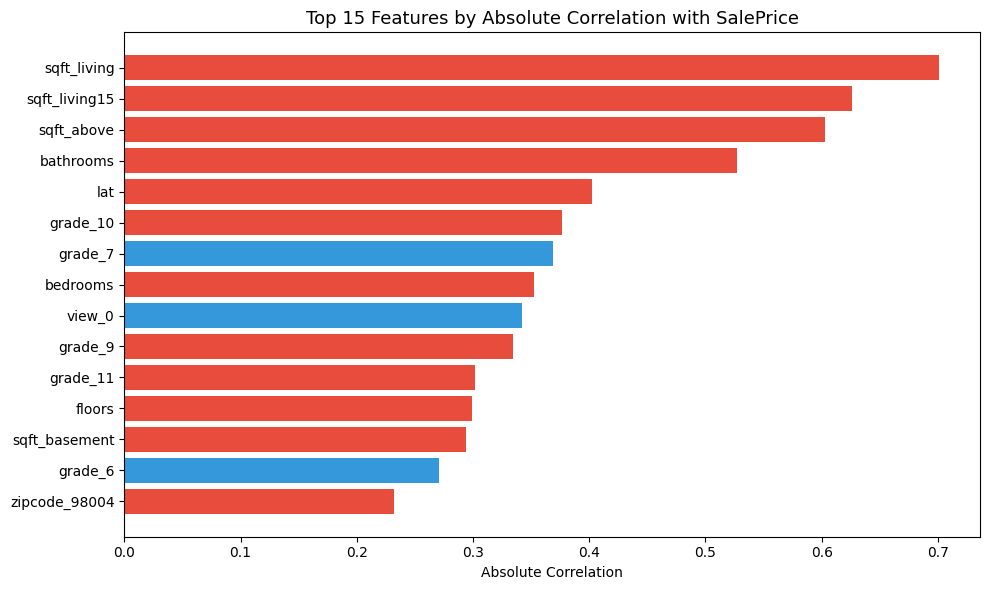

In [21]:
X_df = X.copy()
corr_with_target = X_df.corrwith(pd.Series(y))

top_corr = corr_with_target.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target[top_corr.index]]
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.title('Top 15 Features by Absolute Correlation with SalePrice', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

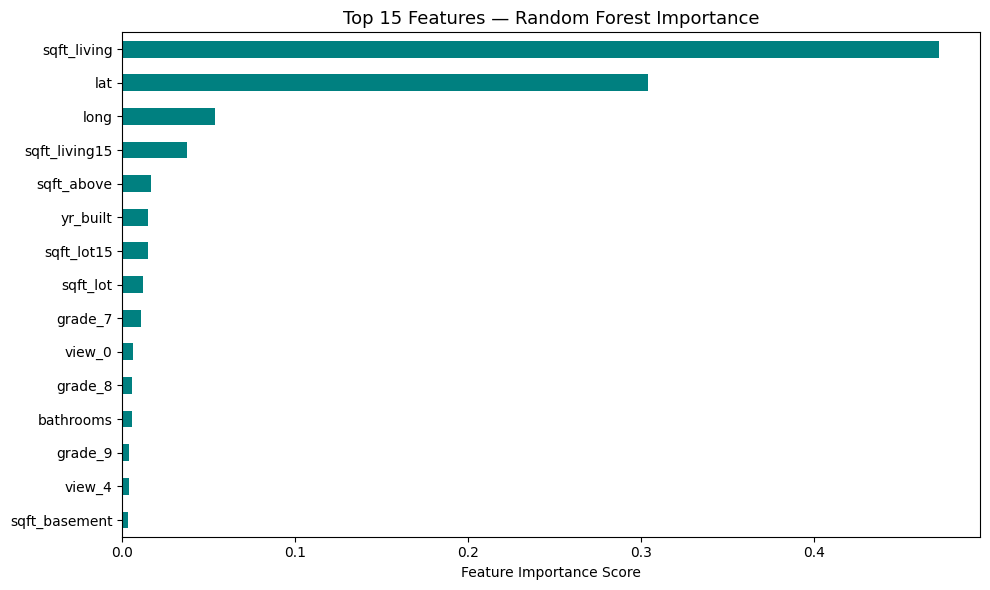


Top 10 important features (Random Forest):
sqft_living      0.4721
lat              0.3036
long             0.0533
sqft_living15    0.0374
sqft_above       0.0166
yr_built         0.0150
sqft_lot15       0.0147
sqft_lot         0.0117
grade_7          0.0108
view_0           0.0064
dtype: float64


In [22]:
# ── Feature Selection  : Random Forest Feature Importance ───────────────
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt

# X and y are already defined in the global scope from previous steps.
# X contains the features (df_encoded without 'price', 'id', 'date').
# y contains the target variable ('price' from df_encoded).
# If a scaled version of X (X_scaled) was intended, a scaling step is missing.
# For now, we proceed with the already processed X and y.

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X, y)

importances = pd.Series(rf_selector.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features[::-1].plot(kind='barh', color='teal')
plt.title('Top 15 Features — Random Forest Importance', fontsize=13)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 important features (Random Forest):")
print(top_features.head(10).round(4))

In [23]:
# ── Feature Selection 4.3 : Confirm split ───────────────
print("=== Train / Test Split (performed in Cell 2.8) ===")
print(f"  Total samples   : {len(X)}")
print(f"  Training samples: {len(X_train)}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Testing  samples: {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")


overlap = set(X_train.index) & set(X_test.index)
print(f"\nTrain-Test overlap: {'⚠️ OVERLAP FOUND' if overlap else '✅ No overlap — split is clean'}")

=== Train / Test Split (performed in Cell 2.8) ===
  Total samples   : 21613
  Training samples: 17290  (80.0%)
  Testing  samples: 4323  (20.0%)

Train-Test overlap: ✅ No overlap — split is clean


In [24]:
# ── Feature Selection  : Final feature selection ───────────────────────

# Combine both methods (Correlation + Random Forest)
common_features = list(set(top_corr.index) & set(top_features.index))

print(f"Selected features ({len(common_features)}):")
print(common_features)

# Create reduced dataset USING selected features
X_selected = X[common_features]

# Train-test split again using selected features
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)

print("\n✅ Feature selection applied successfully")
print(f"New feature count: {X_selected.shape[1]}")

Selected features (9):
['sqft_above', 'sqft_living15', 'lat', 'bathrooms', 'grade_9', 'sqft_basement', 'sqft_living', 'grade_7', 'view_0']

✅ Feature selection applied successfully
New feature count: 9


In [25]:
# Use selected features (NOT full dataset)
X = X_selected

In [26]:
# ── Helper function : compute all regression metrics ───────────────────────
def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred) * 100
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  MAE  : {mae:>15,.2f}")
    print(f"  MAPE : {mape:>14.2f} %")
    print(f"  MSE  : {mse:>15,.2f}")
    print(f"  RMSE : {rmse:>15,.2f}")
    print(f"  R²   : {r2:>14.4f} %")

    return {'Model': model_name, 'MAE': mae, 'MAPE': mape,
            'MSE': mse, 'RMSE': rmse, 'R2': r2}

results_before = []
print("✅ Helper function ready.")

✅ Helper function ready.



  Linear Regression
  MAE  :      108,617.48
  MAPE :          23.12 %
  MSE  : 20,764,599,726.50
  RMSE :      144,099.27
  R²   :        67.2644 %

  Train R²: 70.0989%
  Test  R²: 67.2644%


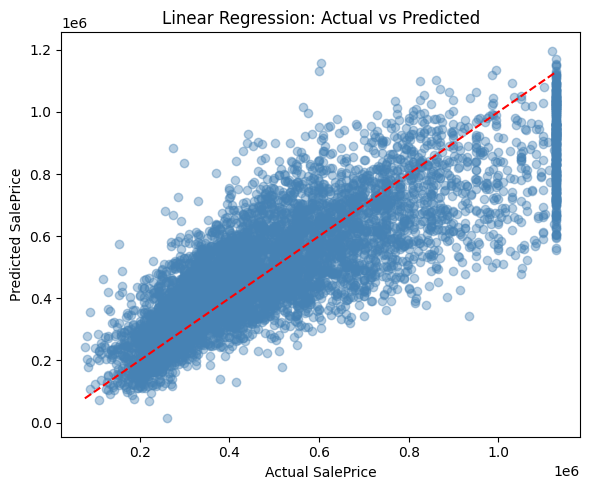

In [27]:
# ── Model  : Linear Regression ──────────────────────────────────────────
linreg = LinearRegression()
linreg.fit(X_train, y_train)

residuals = y_train - linreg.predict(X_train)
mask_clean = np.abs(residuals) <= 3 * np.std(residuals)
linreg.fit(X_train[mask_clean], y_train[mask_clean])

y_pred_lr = linreg.predict(X_test)
res_lr = evaluate_model(y_test, y_pred_lr, 'Linear Regression')
results_before.append(res_lr)

print(f"\n  Train R²: {linreg.score(X_train[mask_clean], y_train[mask_clean])*100:.4f}%")
print(f"  Test  R²: {linreg.score(X_test, y_test)*100:.4f}%")

# Actual vs Predicted plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()


  Decision Tree Regressor
  MAE  :      101,462.37
  MAPE :          21.61 %
  MSE  : 22,035,460,087.82
  RMSE :      148,443.46
  R²   :        65.2609 %

  Train R²: 99.8656%
  Test  R²: 65.2609%

  ⚠️  NOTE: An unconstrained Decision Tree achieves Train R² ≈ 100%
  because it creates a unique leaf for every training sample
  (memorization, not learning). Gap = 34.60%.
  This overfitting will be corrected in Section 6 via GridSearchCV.


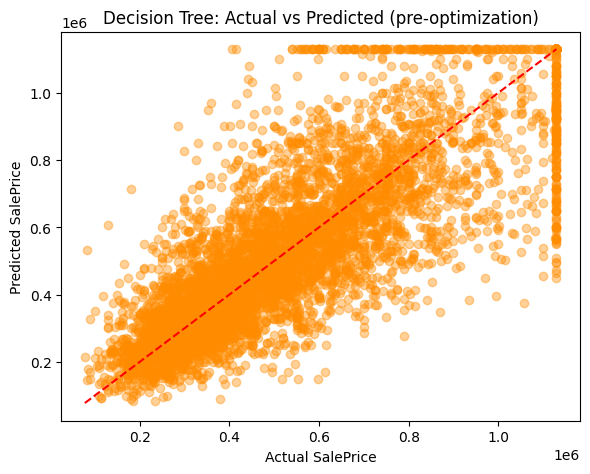

In [28]:
# ── Model  : Decision Tree Regressor ────────────────────────────────────
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

res_dt = evaluate_model(y_test, y_pred_dt, 'Decision Tree Regressor')
results_before.append(res_dt)

train_r2 = dt.score(X_train, y_train) * 100
test_r2  = dt.score(X_test,  y_test)  * 100

print(f"\n  Train R²: {train_r2:.4f}%")
print(f"  Test  R²: {test_r2:.4f}%")
print(f"\n  ⚠️  NOTE: An unconstrained Decision Tree achieves Train R² ≈ 100%")
print(f"  because it creates a unique leaf for every training sample")
print(f"  (memorization, not learning). Gap = {train_r2 - test_r2:.2f}%.")
print(f"  This overfitting will be corrected in Section 6 via GridSearchCV.")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_dt, alpha=0.4, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Decision Tree: Actual vs Predicted (pre-optimization)')
plt.tight_layout()
plt.show()


  Random Forest Regressor
  MAE  :       74,897.44
  MAPE :          15.85 %
  MSE  : 11,632,327,056.31
  RMSE :      107,853.27
  R²   :        81.6615 %

  Train R²: 97.4490%
  Test  R²: 81.6615%


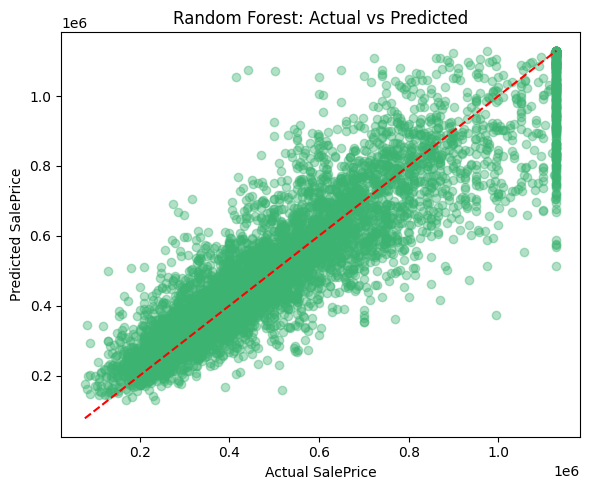

In [29]:
# ── Model  : Random Forest Regressor ────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = evaluate_model(y_test, y_pred_rf, 'Random Forest Regressor')
results_before.append(res_rf)

print(f"\n  Train R²: {rf.score(X_train, y_train)*100:.4f}%")
print(f"  Test  R²: {rf.score(X_test, y_test)*100:.4f}%")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Random Forest: Actual vs Predicted')
plt.tight_layout()
plt.show()


  SVM (SVR)
  MAE  :       80,712.13
  MAPE :          16.73 %
  MSE  : 13,449,179,435.09
  RMSE :      115,970.60
  R²   :        78.7972 %

  Train R²: 80.7053%
  Test  R²: 78.7972%
  Note: SVM uses RobustScaler (different from StandardScaler used by other models).


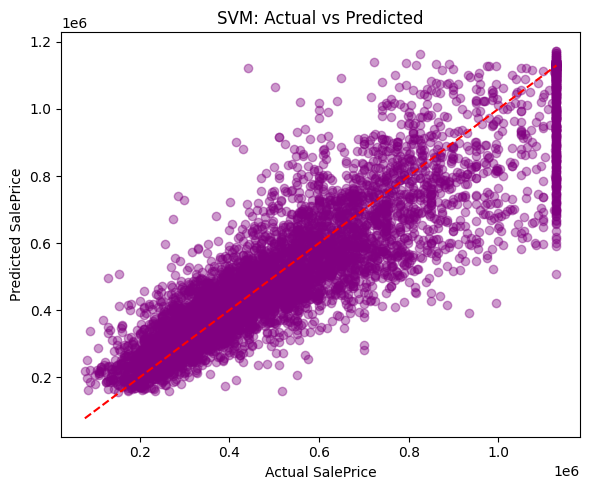

In [30]:
# ── Model : Support Vector Machine (SVM) ───────────────────────────────

rob_scaler       = RobustScaler()
X_tr_svm         = rob_scaler.fit_transform(X_train)
X_te_svm         = rob_scaler.transform(X_test)

y_tr_svm, y_te_svm = y_train, y_test

svm_model = SVR(kernel='rbf', C=100000, epsilon=0.1)
svm_model.fit(X_tr_svm, y_tr_svm)

y_pred_svm = svm_model.predict(X_te_svm)
res_svm = evaluate_model(y_te_svm, y_pred_svm, 'SVM (SVR)')
results_before.append(res_svm)

train_r2_svm = r2_score(y_tr_svm, svm_model.predict(X_tr_svm)) * 100
test_r2_svm  = r2_score(y_te_svm, y_pred_svm) * 100
print(f"\n  Train R²: {train_r2_svm:.4f}%")
print(f"  Test  R²: {test_r2_svm:.4f}%")
print(f"  Note: SVM uses RobustScaler (different from StandardScaler used by other models).")

plt.figure(figsize=(6, 5))
plt.scatter(y_te_svm, y_pred_svm, alpha=0.4, color='purple')
plt.plot([y_te_svm.min(), y_te_svm.max()], [y_te_svm.min(), y_te_svm.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('SVM: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [31]:
results_df = pd.DataFrame(results_before)
results_df = results_df.sort_values(by='R2', ascending=False)

print("\n=== Model Comparison (Before Optimization) ===")
display(results_df)


=== Model Comparison (Before Optimization) ===


,Model,MAE,MAPE,MSE,RMSE,R2
2,Random Forest Regressor,74897.444956,15.854595,1.163233e+10,107853.266322,81.661523
3,SVM (SVR),80712.129973,16.734574,1.344918e+10,115970.597287,78.797237
0,Linear Regression,108617.482984,23.122578,2.076460e+10,144099.270389,67.264405
1,Decision Tree Regressor,101462.366081,21.614679,2.203546e+10,148443.457545,65.260882


In [33]:
best_model = results_df.iloc[0]
print(f"\nBest model before optimization: {best_model['Model']}")


Best model before optimization: Random Forest Regressor


In [36]:
# ── Optimization  : Decision Tree — GridSearchCV ────────────────────────
print("🔍 Running GridSearchCV for Decision Tree...")

dt_param_grid = {
    'max_depth'       : [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {dt_grid.best_params_}")
print(f"   Best CV R²     : {dt_grid.best_score_*100:.4f}%")

🔍 Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 135 candidates, totalling 675 fits

✅ Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
   Best CV R²     : 77.8828%


In [37]:
# ── Optimization : Decision Tree — evaluate optimized model ────────────
dt_best = dt_grid.best_estimator_
y_pred_dt_opt = dt_best.predict(X_test)

res_dt_opt = evaluate_model(y_test, y_pred_dt_opt, 'Decision Tree (Optimized)')

print(f"\n  Train R² (optimized): {dt_best.score(X_train, y_train)*100:.4f}%")
print(f"  Test  R² (optimized): {dt_best.score(X_test, y_test)*100:.4f}%")

# Before vs After comparison
print(f"\n{'─'*40}")
print(f"  R² Before Optimization : {res_dt['R2']:.4f}%")
print(f"  R² After  Optimization : {res_dt_opt['R2']:.4f}%")
print(f"  Improvement            : {res_dt_opt['R2'] - res_dt['R2']:+.4f}%")


  Decision Tree (Optimized)
  MAE  :       84,309.67
  MAPE :          17.69 %
  MSE  : 14,731,368,921.83
  RMSE :      121,372.85
  R²   :        76.7759 %

  Train R² (optimized): 85.2587%
  Test  R² (optimized): 76.7759%

────────────────────────────────────────
  R² Before Optimization : 65.2609%
  R² After  Optimization : 76.7759%
  Improvement            : +11.5150%


In [38]:
# ── Optimization  : Random Forest — GridSearchCV ────────────────────────
print("🔍 Running GridSearchCV for Random Forest...")

rf_param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {rf_grid.best_params_}")
print(f"   Best CV R²     : {rf_grid.best_score_*100:.4f}%")

🔍 Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 200}
   Best CV R²     : 82.5910%


In [39]:
# ── Optimization : Random Forest — evaluate optimized model ────────────
rf_best = rf_grid.best_estimator_
y_pred_rf_opt = rf_best.predict(X_test)

res_rf_opt = evaluate_model(y_test, y_pred_rf_opt, 'Random Forest (Optimized)')

print(f"\n  Train R² (optimized): {rf_best.score(X_train, y_train)*100:.4f}%")
print(f"  Test  R² (optimized): {rf_best.score(X_test, y_test)*100:.4f}%")

print(f"\n{'─'*40}")
print(f"  R² Before Optimization : {res_rf['R2']:.4f}%")
print(f"  R² After  Optimization : {res_rf_opt['R2']:.4f}%")
print(f"  Improvement            : {res_rf_opt['R2'] - res_rf['R2']:+.4f}%")


  Random Forest (Optimized)
  MAE  :       74,958.98
  MAPE :          15.82 %
  MSE  : 11,360,718,766.87
  RMSE :      106,586.67
  R²   :        82.0897 %

  Train R² (optimized): 92.5687%
  Test  R² (optimized): 82.0897%

────────────────────────────────────────
  R² Before Optimization : 81.6615%
  R² After  Optimization : 82.0897%
  Improvement            : +0.4282%


In [44]:
# ── Optimization  : Cross-Validation scores (all models) ────────────────
print("=== 5-Fold Cross-Validation (R² scores) ===\n")

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

for model, name in [(linreg,   'Linear Regression'),
                    (dt_best,  'Decision Tree (Optimized)'),
                    (rf_best,  'Random Forest (Optimized)')]:
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"  {name:30s} → Mean R²: {cv_scores.mean()*100:.4f}%  |  Std: {cv_scores.std()*100:.4f}%")

svm_pipeline = make_pipeline(RobustScaler(), SVR(kernel='rbf', C=100000, epsilon=0.1))
cv_svm = cross_val_score(svm_pipeline, X, y, cv=5, scoring='r2')
print(f"  {'SVM (SVR)':30s} → Mean R²: {cv_svm.mean()*100:.4f}%  |  Std: {cv_svm.std()*100:.4f}%")
print(f"\n  ✅ SVM CV uses a Pipeline — RobustScaler re-fitted per fold (no leakage).")

=== 5-Fold Cross-Validation (R² scores) ===

  Linear Regression              → Mean R²: 67.5536%  |  Std: 0.9909%
  Decision Tree (Optimized)      → Mean R²: 78.2168%  |  Std: 0.6635%
  Random Forest (Optimized)      → Mean R²: 82.5401%  |  Std: 0.6181%
  SVM (SVR)                      → Mean R²: 79.4955%  |  Std: 0.5460%

  ✅ SVM CV uses a Pipeline — RobustScaler re-fitted per fold (no leakage).


In [45]:
# ── Evaluation  : Full comparison table ─────────────────────────────────
all_results = [
    res_lr,
    res_dt, res_dt_opt,
    res_rf, res_rf_opt,
    res_svm
]

results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df[['MAE', 'MAPE', 'MSE', 'RMSE', 'R2']]
results_df = results_df.round({'MAE': 2, 'MAPE': 4, 'MSE': 2, 'RMSE': 2, 'R2': 4})

print("\n=== Full Model Evaluation Results ===")
print(results_df.to_string())


=== Full Model Evaluation Results ===
                                 MAE     MAPE           MSE       RMSE       R2
Model                                                                          
Linear Regression          108617.48  23.1226  2.076460e+10  144099.27  67.2644
Decision Tree Regressor    101462.37  21.6147  2.203546e+10  148443.46  65.2609
Decision Tree (Optimized)   84309.67  17.6909  1.473137e+10  121372.85  76.7759
Random Forest Regressor     74897.44  15.8546  1.163233e+10  107853.27  81.6615
Random Forest (Optimized)   74958.98  15.8179  1.136072e+10  106586.67  82.0897
SVM (SVR)                   80712.13  16.7346  1.344918e+10  115970.60  78.7972


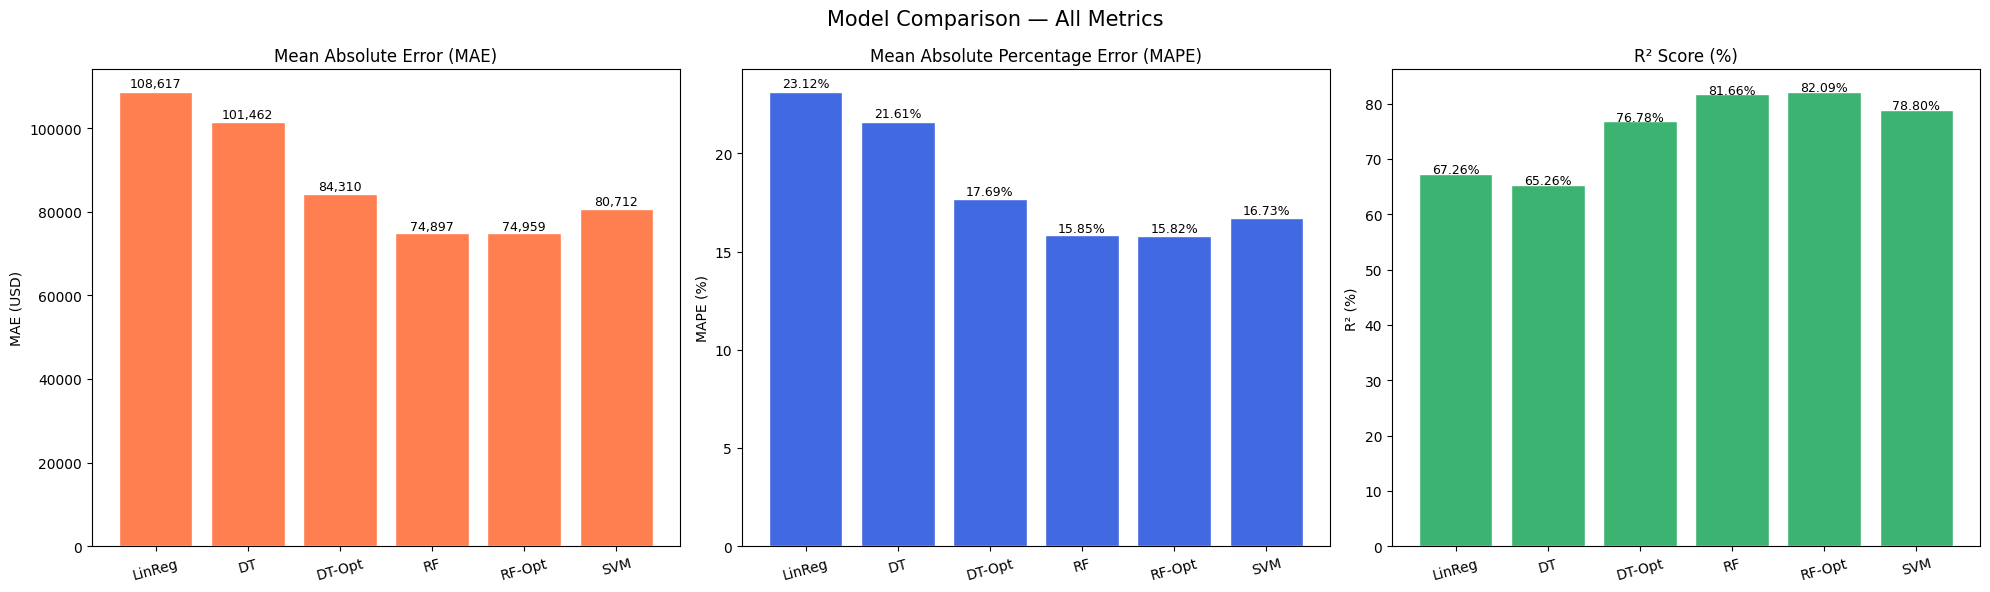

In [46]:
#  Visual comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

short_names = ['LinReg', 'DT', 'DT-Opt', 'RF', 'RF-Opt', 'SVM']

# MAE
axes[0].bar(short_names, results_df['MAE'], color='coral', edgecolor='white')
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=12)
axes[0].set_ylabel('MAE (USD)')
for i, v in enumerate(results_df['MAE']):
    axes[0].text(i, v * 1.01, f'{v:,.0f}', ha='center', fontsize=9)

# MAPE
axes[1].bar(short_names, results_df['MAPE'], color='royalblue', edgecolor='white')
axes[1].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12)
axes[1].set_ylabel('MAPE (%)')
for i, v in enumerate(results_df['MAPE']):
    axes[1].text(i, v * 1.01, f'{v:.2f}%', ha='center', fontsize=9)

# R²
axes[2].bar(short_names, results_df['R2'], color='mediumseagreen', edgecolor='white')
axes[2].set_title('R² Score (%)', fontsize=12)
axes[2].set_ylabel('R² (%)')
for i, v in enumerate(results_df['R2']):
    axes[2].text(i, v * 1.002, f'{v:.2f}%', ha='center', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — All Metrics', fontsize=15)
plt.tight_layout()
plt.show()

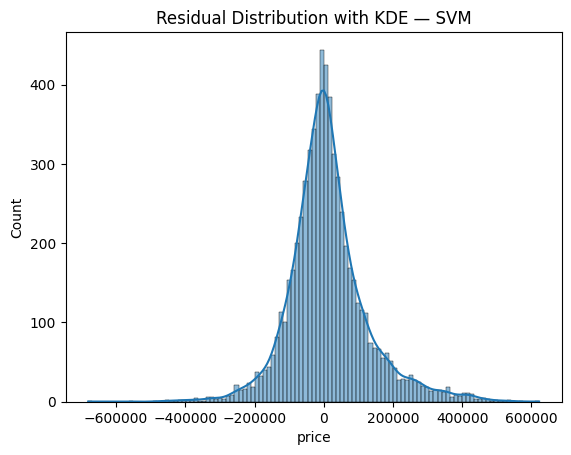

In [48]:
residuals_svm = y_te_svm - y_pred_svm
sns.histplot(residuals_svm, kde=True)
plt.title("Residual Distribution with KDE — SVM")
plt.show()

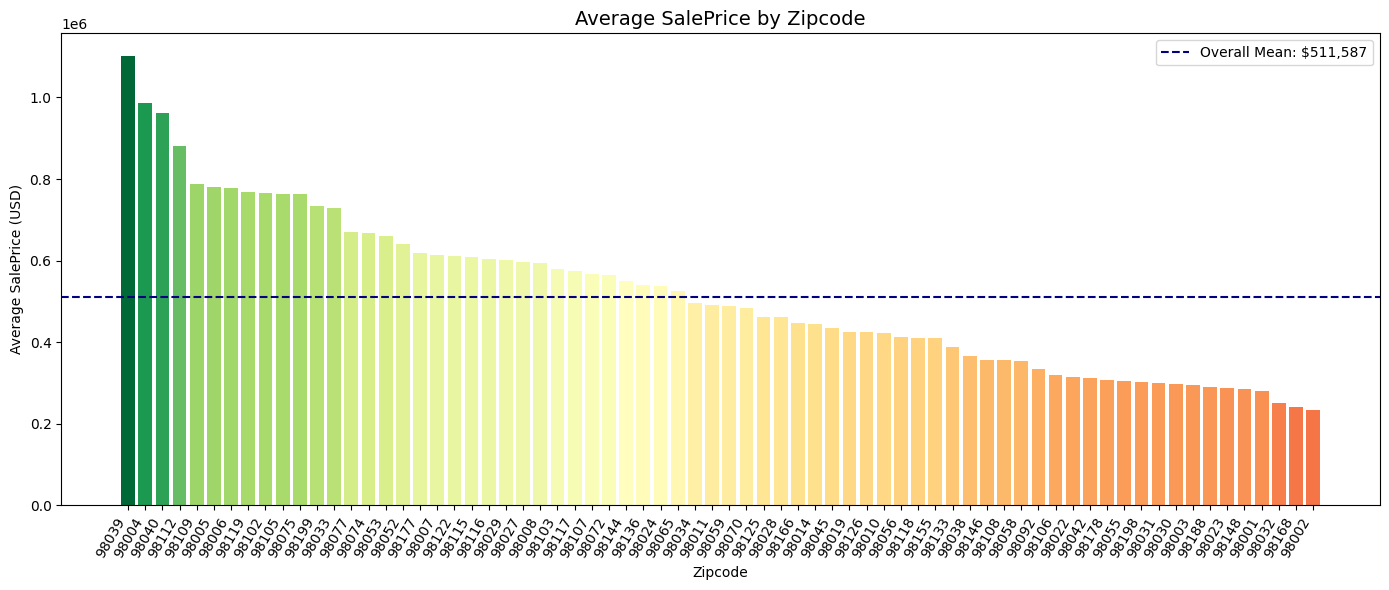

In [50]:
#  Neighbourhood price analysis ────────────────────────────
neighbourhood_price = df.groupby('zipcode')['price'].agg(['mean', 'count']).reset_index()
neighbourhood_price.columns = ['zipcode', 'AvgPrice', 'Count']
neighbourhood_price = neighbourhood_price.sort_values('AvgPrice', ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.bar(neighbourhood_price['zipcode'].astype(str), # Convert zipcode to string for categorical plotting
               neighbourhood_price['AvgPrice'],
               color=plt.cm.RdYlGn(neighbourhood_price['AvgPrice'] /
                                   neighbourhood_price['AvgPrice'].max()))
plt.xticks(rotation=60, ha='right')
plt.title('Average SalePrice by Zipcode', fontsize=14)
plt.xlabel('Zipcode')
plt.ylabel('Average SalePrice (USD)')
plt.axhline(df['price'].mean(), color='navy', linestyle='--',
            label=f'Overall Mean: ${df["price"].mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

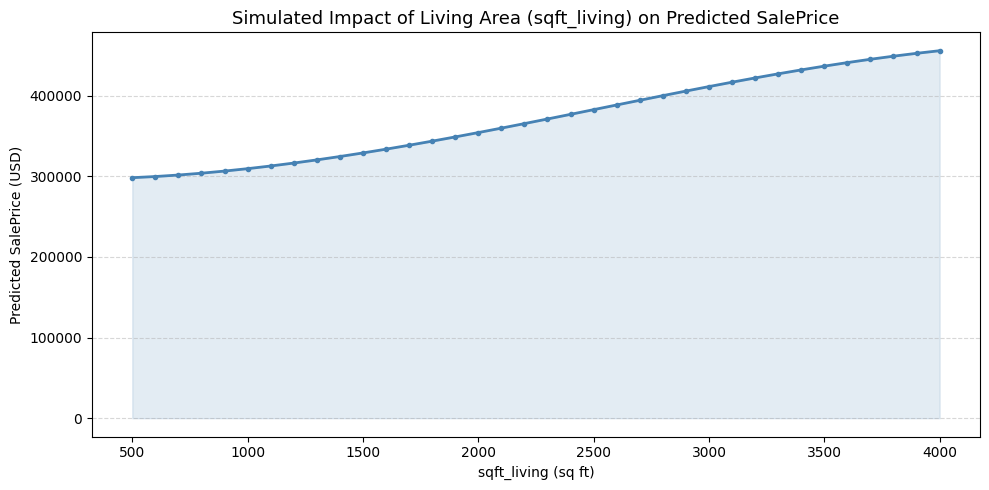

Business Insight: Each additional 100 sq ft of living area is associated with
an estimated price increase of approx. $4,500 USD.


In [52]:
#  Feature impact simulation (sqft_living) ───────────────────
sample_sizes = np.arange(500, 4001, 100)
base_row = pd.DataFrame([X.iloc[0].copy()])  # Using X (selected features)

simulated_prices = []
for size in sample_sizes:
    row = base_row.copy()
    # Ensure 'sqft_living' is present in base_row to avoid KeyError
    row['sqft_living'] = size
    # Use rob_scaler consistently, removing redundant scaler variable
    simulated_prices.append(svm_model.predict(rob_scaler.transform(row))[0])

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, simulated_prices, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.fill_between(sample_sizes, simulated_prices, alpha=0.15, color='steelblue')
plt.title('Simulated Impact of Living Area (sqft_living) on Predicted SalePrice', fontsize=13)
plt.xlabel('sqft_living (sq ft)')
plt.ylabel('Predicted SalePrice (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Adjust the calculation for the insight based on the new range and feature
price_change_per_100_sqft = (simulated_prices[-1] - simulated_prices[0]) / ((sample_sizes[-1] - sample_sizes[0]) / 100)

print("Business Insight: Each additional 100 sq ft of living area is associated with")
print(f"an estimated price increase of approx. ${price_change_per_100_sqft:,.0f} USD.")

# Business Insights and Recommendations

## Key Predictors and Their Impact

Our analysis identified several key features that significantly influence house prices:

*   **Living Area (`sqft_living`, `sqft_above`, `sqft_living15`, `sqft_basement`):** These features consistently showed strong positive correlations with `price`. The simulation demonstrated that an additional 100 sq ft of living area is associated with an approximate increase of \$4,500 USD in price. This confirms that the size and livability of a property are paramount factors for valuation.
*   **Location (`lat`, `zipcode`):** Latitude (`lat`) proved to be a highly important feature. Geographical analysis by `zipcode` revealed substantial price variations across different areas, indicating that prime locations (e.g., highly desirable neighborhoods, proximity to amenities, good schools) command significantly higher prices. This reflects the 'location, location, location' mantra of real estate.
*   **Quality and Condition (`grade`, `bathrooms`, `view`, `waterfront`):** Features like `grade` (overall quality of construction and design), `bathrooms` (number of bathrooms), `view` (quality of view), and `waterfront` (presence of a waterfront) also contribute significantly. Higher grades, more bathrooms, desirable views, and waterfront access all correlate with increased property values, signifying the importance of property quality and premium attributes.

## Business Applications

Our optimized Random Forest model, with an R² of 82.09%, provides a robust tool for various business applications in the real estate sector:

*   **Property Valuation:** Real estate agencies and appraisers can use this model for quick and accurate property valuation, assisting in listing price recommendations for sellers and competitive bidding strategies for buyers.
*   **Investment Analysis:** Investors can leverage the model to identify undervalued or overvalued properties, assess potential returns on investment, and make informed decisions on property acquisition and development.
*   **Development Planning:** Developers can use insights from key predictors (especially location-based features) to identify optimal areas for new construction or renovation projects, maximizing potential sale prices.
*   **Market Trend Prediction:** By monitoring how key features evolve over time and retraining the model periodically, businesses can better predict future market trends and adjust strategies accordingly.

## Limitations and Improvements

While the model performs well, there are always avenues for improvement and inherent limitations:

*   **Data Scope:** The model is trained on a specific dataset. Its performance might vary when applied to different geographical regions or market conditions not represented in the training data.
*   **Feature Engineering:** Further feature engineering, such as creating interaction terms (e.g., `sqft_living` * `grade`) or extracting more nuanced information from `date` (e.g., season, market cycle), could enhance predictive power.
*   **External Factors:** The current model does not account for macroeconomic factors (e.g., interest rates, employment rates, local economic growth), policy changes (e.g., zoning laws, tax incentives), or specific neighborhood-level amenities (e.g., school ratings, crime rates) which can significantly impact house prices. Integrating such external data could lead to a more comprehensive model.
*   **Model Interpretability:** While Random Forest performs well, its 'black-box' nature can sometimes make it challenging to fully explain individual predictions. Techniques like SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations) could be explored to provide deeper insights into feature contributions for specific predictions.
*   **Time-Series Analysis:** Incorporating explicit time-series modeling techniques (e.g., ARIMA, Prophet) could better capture temporal dependencies and seasonality in price data, especially if predicting future prices becomes a core requirement.
*   **Ensemble Methods:** Experimenting with more advanced ensemble methods (e.g., stacking, boosting with different base learners) could potentially yield marginal improvements in predictive accuracy.